In [336]:
import json
from seaborn import lineplot
from collections import defaultdict

In [337]:
data = [] 
with open('politiquices_data_v1.0.jsonl') as f_in:
    for line in f_in.readlines():
        data.append(json.loads(line))

In [338]:
len(data)

3324

In [339]:
data[158]

{'title': 'Ana Gomes defende Durão Barroso',
 'label': 'ent1_supports_ent2',
 'date': '2002-05-11 08:26:00',
 'url': 'http://www.publico.pt/141932',
 'ent1': 'Ana Gomes',
 'ent2': 'Durão Barroso',
 'ent1_id': 'http://www.wikidata.org/entity/Q2844986',
 'ent2_id': 'http://www.wikidata.org/entity/Q15849'}

In [340]:
import spacy
nlp = spacy.load("pt_core_news_lg")

In [341]:
pre_processed = [nlp(doc['title']) for doc in data]

In [348]:
data[0]

{'title': 'Paulo Portas faz participação disciplinar de Daniel Campelo',
 'label': 'ent1_opposes_ent2',
 'date': '2000-11-14 23:32:00',
 'url': 'http://www.publico.pt/33',
 'ent1': 'Paulo Portas',
 'ent2': 'Daniel Campelo',
 'ent1_id': 'http://www.wikidata.org/entity/Q58161',
 'ent2_id': 'http://www.wikidata.org/entity/Q10263926'}

In [374]:
msg_tokens = []
msg_size_all = []
msg_size_support = []
msg_size_oppose = []
msg_size_other = []

for nlp_doc, sample in zip(pre_processed, data):
    entities = sample['ent1'].split() + sample['ent2'].split()
    tokens = []
    for token in nlp_doc:
        if token.text in entities:
            continue
        tokens.append(token.text)
    msg_tokens.append(tokens)
    if 'opposes' in sample['label']:
        msg_size_oppose.append(len(tokens))
    if 'supports' in sample['label']:
        msg_size_support.append(len(tokens))
    if 'other' in sample['label']:
        msg_size_other.append(len(tokens))

In [375]:
from statistics import median, stdev, mean

## opposes

In [392]:
print("median: ", median(msg_size_oppose))
print("mean  : ", mean(msg_size_oppose))
print("max   : ", max(msg_size_oppose))
print("min   : ", min(msg_size_oppose))

median:  8
mean  :  8.264916467780429
max   :  22
min   :  1


## support

In [393]:
print("median: ", median(msg_size_support))
print("mean  : ", mean(msg_size_support))
print("max   : ", max(msg_size_support))
print("min   : ", min(msg_size_support))

median:  7
mean  :  7.353482260183968
max   :  17
min   :  1


## other

In [394]:
print("median: ", median(msg_size_other))
print("mean  : ", mean(msg_size_other))
print("max   : ", max(msg_size_other))
print("min   : ", min(msg_size_other))

median:  8.0
mean  :  8.029096477794793
max   :  18
min   :  1


In [296]:
entries_freq = defaultdict(int)
not_linked = defaultdict(int)
for entry in data:
    if entry['ent1_id'] != 'None':
        entries_freq[entry['ent1_id'].split("/")[-1]] += 1
    else:
        not_linked[entry['ent1']] += 1
    
    if entry['ent2_id'] != 'None':
        entries_freq[entry['ent2_id'].split("/")[-1]] += 1
    else:
        not_linked[entry['ent2']] += 1

In [297]:
data = {e[0]: e[1] for e in sorted(entries_freq.items(), key=lambda x: x[1], reverse=True)}

In [298]:
total = sum([e for e in data.values()])
print(f"{len(not_linked)+len(data)} entidades únicas.")
print(f"{len(not_linked)} entidades únicas e sem identificador na WikiData.")
print(f"{len(data)} entidades únicas e com identificador na WikiData.")
acc = 0
for idx, e in enumerate(data.items()):
    if acc >= total*0.8:
        print(f"{idx} ({float(idx/len(data))*100:.2f}%) entidades são responsáveis por 80% dos dados")
        break
    acc += e[1]

644 entidades únicas.
129 entidades únicas e sem identificador na WikiData.
515 entidades únicas e com identificador na WikiData.
96 (18.64%) entidades são responsáveis por 80% dos dados


In [320]:
x_entites = range(0,len(data.items()))
new_names = []
for n,i in enumerate(x_entites):
    if n%50==0:
        new_names.append(i)
    else:
        new_names.append('')

/var/folders/sh/dxqtyznd5yjg8gvbcl906j100000gn/T/ipykernel_24870/3798805919.py:2: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set(xticklabels=new_names)


Text(101, 60, '96 entidades representam 80% das ocorrências')

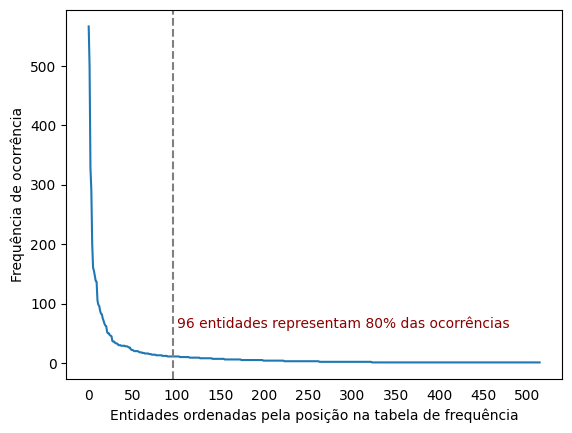

In [325]:
g = lineplot(data=data, alpha=1)
g.set(xticklabels=new_names)
g.set(xlabel="Entidades ordenadas pela posição na tabela de frequência")
g.tick_params(bottom=False)
g.set(title='')
g.set(ylabel="Frequência de ocorrência")
g.axvline(idx, color='.5', linestyle='--')
g.text(idx+5,60,f"{idx} entidades representam 80% das ocorrências",rotation=0, color='darkred')

In [328]:
fig = g.get_figure()
fig.savefig('../paper/power_law_ent_freq.png', dpi=1200)